In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score
import seaborn as sns
import time

In [2]:
import kagglehub

path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


In [3]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder('/kaggle/input/chest-xray-pneumonia/chest_xray/train', transform=train_transforms)
test_dataset = datasets.ImageFolder('/kaggle/input/chest-xray-pneumonia/chest_xray/test', transform=test_transforms)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f'Размер тренировочной выборки: {len(train_dataset)}')
print(f'Размер тестовой выборки: {len(test_dataset)}')

Размер тренировочной выборки: 5216
Размер тестовой выборки: 624


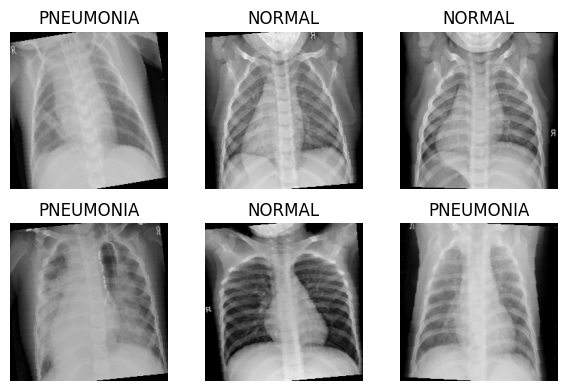

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(6, 4))
for i in range(6):
    idx = np.random.randint(0, len(train_dataset))
    img, label = train_dataset[idx]
    img = img.permute(1, 2, 0).numpy()
    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img = np.clip(img, 0, 1)
    axes[i//3, i%3].imshow(img)
    axes[i//3, i%3].set_title('NORMAL' if label == 0 else 'PNEUMONIA')
    axes[i//3, i%3].axis('off')
plt.tight_layout()
plt.show()

In [8]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(128 * 28 * 28, 512)
        self.fc2 = nn.Linear(512, 2)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))
        x = x.view(-1, 128 * 28 * 28)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_simple = SimpleCNN().to(device)

print(model_simple)
print(f'\nКоличество параметров: {sum(p.numel() for p in model_simple.parameters())}')

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_simple.parameters(), lr=0.001)

SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=100352, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=2, bias=True)
  (relu): ReLU()
)

Количество параметров: 51475010


In [9]:
epochs = 10
train_losses = []
train_accs = []
start_time = time.time()

for epoch in range(epochs):
    model_simple.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model_simple(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)
    print(f'Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%')

end_time = time.time()
print(f'Training time: {end_time - start_time:.2f} seconds')

Epoch 1/10, Loss: 0.2941, Accuracy: 88.88%
Epoch 2/10, Loss: 0.1237, Accuracy: 95.55%
Epoch 3/10, Loss: 0.1060, Accuracy: 96.05%
Epoch 4/10, Loss: 0.1020, Accuracy: 96.26%
Epoch 5/10, Loss: 0.0959, Accuracy: 96.38%
Epoch 6/10, Loss: 0.0926, Accuracy: 96.66%
Epoch 7/10, Loss: 0.0738, Accuracy: 97.20%
Epoch 8/10, Loss: 0.0777, Accuracy: 96.84%
Epoch 9/10, Loss: 0.0736, Accuracy: 97.32%
Epoch 10/10, Loss: 0.0690, Accuracy: 97.22%
Training time: 1011.13 seconds


Accuracy: 0.7676
Sensitivity: 0.9846
Specificity: 0.4060


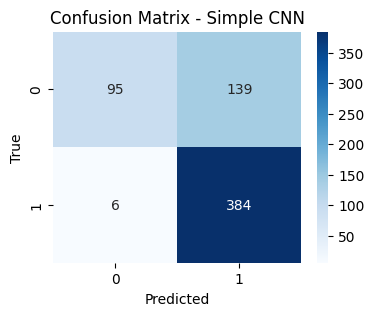

In [11]:
model_simple.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model_simple(images)
        _, predicted = torch.max(outputs.data, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

accuracy = accuracy_score(y_true, y_pred)
sensitivity = recall_score(y_true, y_pred, pos_label=1)
specificity = recall_score(y_true, y_pred, pos_label=0)

print(f'Accuracy: {accuracy:.4f}')
print(f'Sensitivity: {sensitivity:.4f}')
print(f'Specificity: {specificity:.4f}')

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.title('Confusion Matrix - Simple CNN')
plt.show()

In [14]:
model_resnet = models.resnet18(pretrained=True)

for param in model_resnet.parameters():
    param.requires_grad = False

num_features = model_resnet.fc.in_features
model_resnet.fc = nn.Linear(num_features, 2)
model_resnet = model_resnet.to(device)

print(model_resnet)
print(f'\nКоличество параметров: {sum(p.numel() for p in model_resnet.parameters())}')

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_resnet.fc.parameters(), lr=0.001)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [15]:
epochs = 10
start_time = time.time()

for epoch in range(epochs):
    model_resnet.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model_resnet(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    print(f'Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%')

end_time = time.time()
print(f'Training time: {end_time - start_time:.2f} seconds')

Epoch 1/10, Loss: 0.2830, Accuracy: 88.13%
Epoch 2/10, Loss: 0.1874, Accuracy: 92.27%
Epoch 3/10, Loss: 0.1562, Accuracy: 94.04%
Epoch 4/10, Loss: 0.1456, Accuracy: 94.19%
Epoch 5/10, Loss: 0.1394, Accuracy: 94.59%
Epoch 6/10, Loss: 0.1398, Accuracy: 94.56%
Epoch 7/10, Loss: 0.1299, Accuracy: 94.96%
Epoch 8/10, Loss: 0.1300, Accuracy: 94.90%
Epoch 9/10, Loss: 0.1328, Accuracy: 94.92%
Epoch 10/10, Loss: 0.1327, Accuracy: 94.69%
Training time: 919.08 seconds


In [16]:
model_resnet.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model_resnet(images)
        _, predicted = torch.max(outputs.data, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

accuracy = accuracy_score(y_true, y_pred)
sensitivity = recall_score(y_true, y_pred, pos_label=1)
specificity = recall_score(y_true, y_pred, pos_label=0)

print(f'Accuracy: {accuracy:.4f}')
print(f'Sensitivity: {sensitivity:.4f}')
print(f'Specificity: {specificity:.4f}')

Accuracy: 0.7837
Sensitivity: 0.9974
Specificity: 0.4274


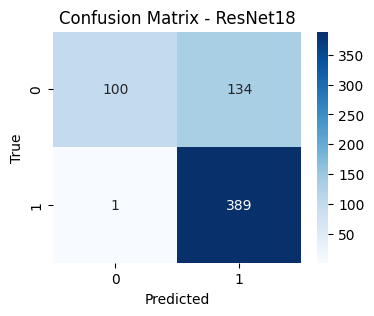

In [18]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.title('Confusion Matrix - ResNet18')
plt.show()

Forward hook
Backward hook


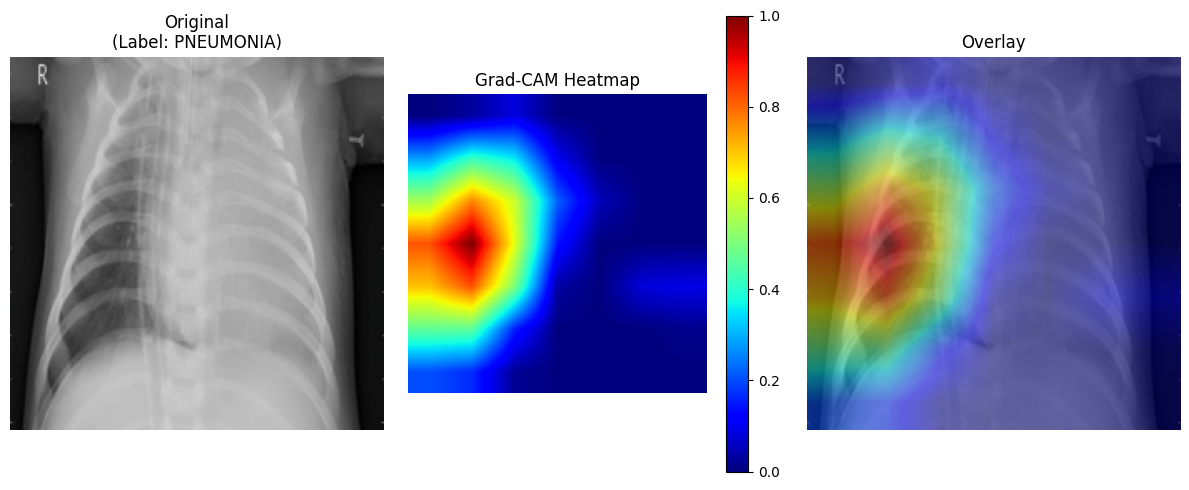

Model prediction: PNEUMONIA (confidence: 1.00)


In [53]:
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0]
            print(f"Backward hook")

        def forward_hook(module, input, output):
            self.activations = output
            print(f"Forward hook")

        self.forward_handle = target_layer.register_forward_hook(forward_hook)
        self.backward_handle = target_layer.register_full_backward_hook(backward_hook)

    def generate(self, input_image, target_class=None):
        self.model.eval()

        input_image = input_image.clone().detach().requires_grad_(True)

        output = self.model(input_image)

        if target_class is None:
            target_class = output.argmax(dim=1).item()

        self.model.zero_grad()
        class_loss = output[0, target_class]
        class_loss.backward()

        if self.gradients is None:
            raise ValueError(f"Gradients not captured!")
        if self.activations is None:
            raise ValueError("Activations not captured!")

        gradients = self.gradients.cpu().data.numpy()[0]
        activations = self.activations.cpu().data.numpy()[0]

        weights = np.mean(gradients, axis=(1, 2))
        cam = np.zeros(activations.shape[1:], dtype=np.float32)

        for i, w in enumerate(weights):
            cam += w * activations[i]

        cam = np.maximum(cam, 0)
        cam = cv2.resize(cam, (224, 224))
        if np.max(cam) == 0:
            print("Warning: CAM is all zeros")
        else:
            cam = cam - np.min(cam)
            cam = cam / np.max(cam)

        self.forward_handle.remove()
        self.backward_handle.remove()

        return cam

test_img, test_label = test_dataset[358]
test_img_tensor = test_img.unsqueeze(0).to(device)

target_layer = model_resnet.layer4[-1].conv2
grad_cam = GradCAM(model_resnet, target_layer)
heatmap = grad_cam.generate(test_img_tensor)

plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
img = test_img.permute(1, 2, 0).numpy()
img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
img = np.clip(img, 0, 1)
plt.imshow(img)
plt.title(f'Original\n(Label: {"PNEUMONIA" if test_label == 1 else "NORMAL"})')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(heatmap, cmap='jet')
plt.title('Grad-CAM Heatmap')
plt.colorbar()
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img)
plt.imshow(heatmap, cmap='jet', alpha=0.5)
plt.title('Overlay')
plt.axis('off')

plt.tight_layout()
plt.show()

with torch.no_grad():
    pred = model_resnet(test_img_tensor).argmax(dim=1).item()
    confidence = torch.softmax(model_resnet(test_img_tensor), dim=1).max().item()
    print(f"Model prediction: {'PNEUMONIA' if pred == 1 else 'NORMAL'} (confidence: {confidence:.2f})")

Forward hook
Backward hook


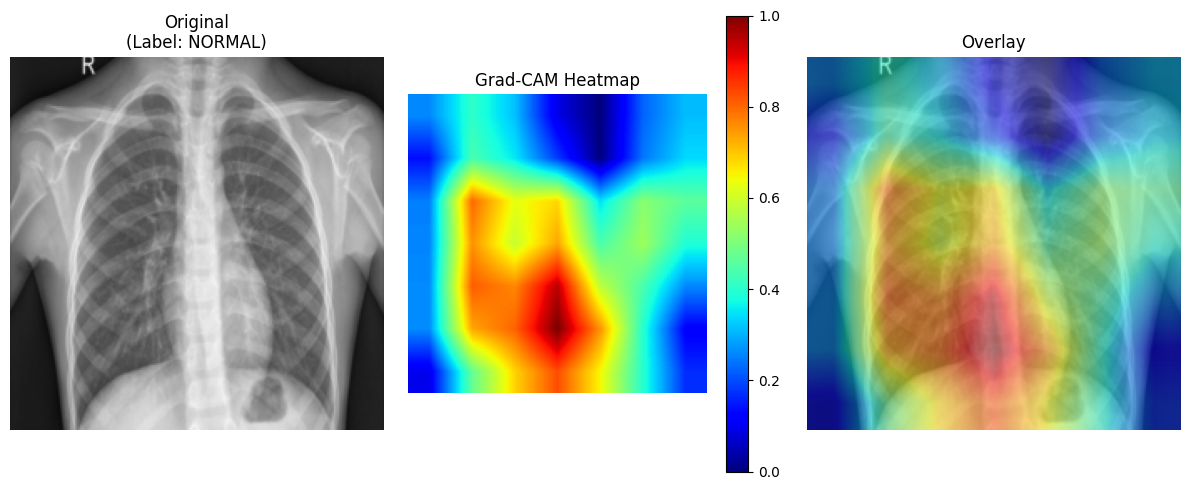

Model prediction: NORMAL (confidence: 0.68)


In [54]:
test_img, test_label = test_dataset[0]
test_img_tensor = test_img.unsqueeze(0).to(device)

target_layer = model_resnet.layer4[-1].conv2
grad_cam = GradCAM(model_resnet, target_layer)
heatmap = grad_cam.generate(test_img_tensor)

plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
img = test_img.permute(1, 2, 0).numpy()
img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
img = np.clip(img, 0, 1)
plt.imshow(img)
plt.title(f'Original\n(Label: {"PNEUMONIA" if test_label == 1 else "NORMAL"})')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(heatmap, cmap='jet')
plt.title('Grad-CAM Heatmap')
plt.colorbar()
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img)
plt.imshow(heatmap, cmap='jet', alpha=0.5)
plt.title('Overlay')
plt.axis('off')

plt.tight_layout()
plt.show()

with torch.no_grad():
    pred = model_resnet(test_img_tensor).argmax(dim=1).item()
    confidence = torch.softmax(model_resnet(test_img_tensor), dim=1).max().item()
    print(f"Model prediction: {'PNEUMONIA' if pred == 1 else 'NORMAL'} (confidence: {confidence:.2f})")